
# Perceptrón Multicapa (MLP) para clasificar flores Iris



In [ ]:
!pip -q install seaborn


# 1. Descripción de scikit-learn, clases y funciones para crear un Multi-layer Perceptron

## ¿Qué es scikit-learn?
`scikit-learn` es una biblioteca de Python orientada al aprendizaje automático supervisado y no supervisado. Se caracteriza por:

- una API consistente,
- integración con `NumPy`, `pandas` y `matplotlib`,
- modelos listos para usar,
- utilidades de preprocesamiento, partición y evaluación.

## Clases y funciones que usaremos para construir el MLP

### 1. `load_iris`
Carga el dataset clásico de flores Iris.

```python
from sklearn.datasets import load_iris
```

### 2. `train_test_split`
Divide el conjunto de datos en entrenamiento y prueba.

```python
from sklearn.model_selection import train_test_split
```

### 3. `StandardScaler`
Estandariza las variables numéricas para que tengan media 0 y desviación estándar 1.

```python
from sklearn.preprocessing import StandardScaler
```

### 4. `MLPClassifier`
Implementa un **Perceptrón Multicapa** para clasificación.

```python
from sklearn.neural_network import MLPClassifier
```

### 5. Métricas de evaluación
Usaremos:

```python
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
```



# 2. Descripción del dataset: variables, tipos e interpretación

Trabajaremos con el **Iris dataset**, uno de los conjuntos de datos más conocidos en aprendizaje automático. Contiene **150 flores** distribuidas en **3 clases**:

- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Cada flor está descrita por **4 variables numéricas**:

1. `sepal length (cm)` → longitud del sépalo  
2. `sepal width (cm)` → anchura del sépalo  
3. `petal length (cm)` → longitud del pétalo  
4. `petal width (cm)` → anchura del pétalo  

La variable objetivo es:

5. `target` → especie de flor

## Tipo de variables
- Las 4 variables predictoras son **continuas numéricas**.
- La variable objetivo es **categórica nominal** con 3 clases.


In [ ]:

import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X = iris.data.copy()
y = iris.target.copy()

df = X.copy()
df["target"] = y
df["species"] = df["target"].map({i:name for i, name in enumerate(iris.target_names)})

print("Dimensión del dataset:", df.shape)
df.head()


Dimensión del dataset: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



#  Dataset Iris en scikit-learn

## Paso 1: Carga del dataset

```python
iris = load_iris(as_frame=True)
```

Esta instrucción carga el dataset Iris y devuelve un objeto tipo **Bunch**, que es similar a un diccionario.

### Componentes relevantes:
- `iris.data` → DataFrame con variables predictoras
- `iris.target` → vector de etiquetas
- `iris.target_names` → nombres de las clases

### Interpretación matemática:

Se tiene un conjunto de datos:

$$D = {(x^{(i)}, y^{(i)}} para i = 1,...,150$$

donde:
- $x^{(i)} ∈ R^4$
- $y^{(i)} ∈ {0,1,2}$

---

## Separación en X y y

```python
$X = iris.data.copy()$
$y = iris.target.copy()$
```

- X es una matriz de dimensión (150 × 4)
- y es un vector de dimensión (150)

Se usa `.copy()` para evitar modificar los datos originales.

---

## Construcción del DataFrame

```python
df = X.copy()
```

Se crea un DataFrame independiente con las variables de entrada.

---

## Agregar la variable objetivo

```python
df["target"] = y
```

Ahora el DataFrame tiene dimensión (150 × 5), donde la nueva columna es la variable objetivo.

---

## Mapeo a etiquetas semánticas

```python
df["species"] = df["target"].map({i:name for i, name in enumerate(iris.target_names)})
```

### Paso 1: Construcción del diccionario

```python
{
  0: "setosa",
  1: "versicolor",
  2: "virginica"
}
```

### Paso 2Aplicación de map

Se define una función:

g: {0,1,2} → {setosa, versicolor, virginica}

y se aplica elemento a elemento:

$$y^{(i)} → g(y^{(i)})$$

---

## Resultado final

El DataFrame queda como:

$$[x1, x2, x3, x4, target, species]$$

donde:
- $x ∈ R^4$
- $target ∈ {0,1,2}$
- species es la representación textual

---

## Interpretación conceptual

Este código realiza tres tareas fundamentales:

1. Define el espacio de entrada $X ⊂ R^4$
2. Define la variable objetivo $y ∈ {0,1,2}$  
3. Construye una representación interpretable species  

---

## Nota importante

El modelo de Machine Learning (MLP) utiliza **target**, no **species**.

La columna **species** se usa únicamente para:
- interpretación
- visualización
- análisis


In [ ]:

print("Columnas del dataset:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nDescripción estadística:")
display(df.describe())


Columnas del dataset:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

Tipos de datos:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species               object
dtype: object

Descripción estadística:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



# 3. Imágenes de diferentes flores

El dataset Iris clásico en `scikit-learn` es **tabular**: contiene medidas numéricas, no fotografías embebidas.  
Para apoyar la interpretación del problema, mostramos **imágenes representativas** de las tres especies.


In [ ]:

from IPython.display import display, HTML

display(HTML("""
<div style="display:flex; gap:20px; flex-wrap:wrap;">
  <div style="text-align:center;">
    <img src="https://raw.githubusercontent.com/MarcSkovMadsen/awesome-streamlit/master/gallery/iris_eda_app/imgs/iris_setosa.jpg" width="240"><br>
    <b>Iris setosa</b>
  </div>
  <div style="text-align:center;">
    <img src="https://raw.githubusercontent.com/MarcSkovMadsen/awesome-streamlit/master/gallery/iris_eda_app/imgs/iris_versicolor.jpg" width="240"><br>
    <b>Iris versicolor</b>
  </div>
  <div style="text-align:center;">
    <img src="https://raw.githubusercontent.com/MarcSkovMadsen/awesome-streamlit/master/gallery/iris_eda_app/imgs/iris_virginica.jpg" width="240"><br>
    <b>Iris virginica</b>
  </div>
</div>
"""))



# 4. Descripción del problema de clasificación que enfrentará el MLP

Este problema es una **clasificación multiclase supervisada**.

## Entrada
Cada ejemplo es un vector de 4 medidas:

$$
x = [\text{sepal length},\ \text{sepal width},\ \text{petal length},\ \text{petal width}]
$$

## Salida
La salida deseada es una de tres clases:

$$
y \in \{0,1,2\}
$$

que corresponden a:
- 0 → setosa
- 1 → versicolor
- 2 → virginica


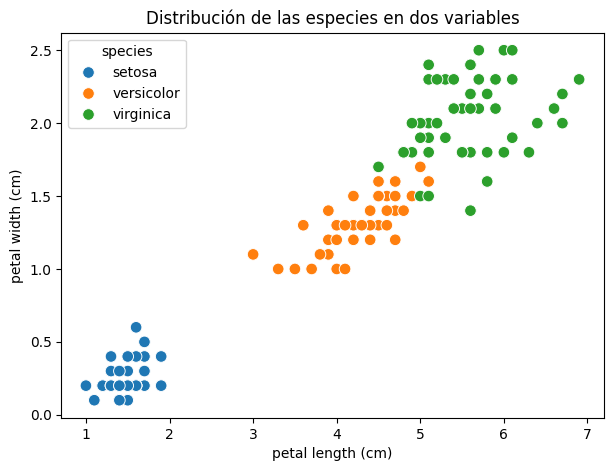

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)", hue="species", s=70)
plt.title("Distribución de las especies en dos variables")
plt.show()



# 5. Setting up Red Neuronal (Arquitectura, parámetros, imagen)

En el sitio se utiliza `MLPClassifier` con la siguiente arquitectura:

```python
MLPClassifier(hidden_layer_sizes=(10,10,10), max_iter=1000)
```

Eso significa:

\[
4 \rightarrow 10 \rightarrow 10 \rightarrow 10 \rightarrow 3
\]

donde:
- 4 neuronas de entrada,
- 3 capas ocultas de 10 neuronas cada una,
- 3 neuronas de salida implícitas para clasificación multiclase.


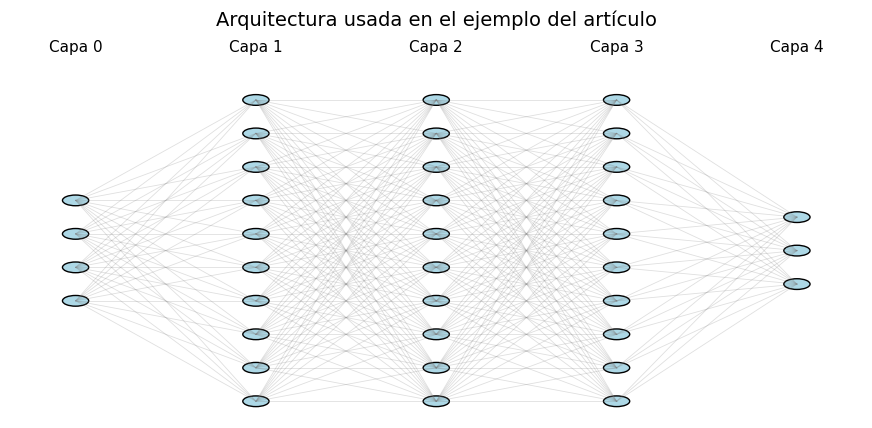

In [ ]:

import matplotlib.pyplot as plt

def draw_mlp_architecture(layer_sizes, title="Arquitectura del MLP"):
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.axis("off")
    x_spacing = 2.2
    max_neurons = max(layer_sizes)

    for layer_idx, n_neurons in enumerate(layer_sizes):
        y_offset = (max_neurons - n_neurons) / 2
        for neuron_idx in range(n_neurons):
            x = layer_idx * x_spacing
            y = neuron_idx + y_offset
            circle = plt.Circle((x, y), 0.16, color="lightblue", ec="black")
            ax.add_patch(circle)
            if layer_idx < len(layer_sizes) - 1:
                next_n = layer_sizes[layer_idx + 1]
                next_y_offset = (max_neurons - next_n) / 2
                for next_idx in range(next_n):
                    x2 = (layer_idx + 1) * x_spacing
                    y2 = next_idx + next_y_offset
                    ax.plot([x, x2], [y, y2], color="gray", alpha=0.25, linewidth=0.6)

        ax.text(layer_idx * x_spacing, max_neurons + 0.45, f"Capa {layer_idx}", ha="center", fontsize=11)

    ax.set_xlim(-0.8, x_spacing*(len(layer_sizes)-1)+0.8)
    ax.set_ylim(-0.5, max_neurons+1.0)
    ax.set_title(title, fontsize=14)
    plt.show()

draw_mlp_architecture([4,10,10,10,3], title="Arquitectura usada en el ejemplo del artículo")



# 6. Preprocesamiento del dataset

## ¿Por qué emplear `StandardScaler`?

Una red neuronal es sensible a la escala de las variables. Si una variable tiene magnitudes mucho mayores que otra, puede dominar los gradientes y dificultar el aprendizaje.

La fórmula de estandarización es:

$$
z = \frac{x - \mu}{\sigma}
$$

donde:
- $\mu$ = media de la variable,
- $\sigma$
 = desviación estándar de la variable.


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Antes de escalar:")
display(X_train.describe().loc[["mean", "std", "min", "max"]])

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print("\nDespués de escalar:")
display(X_train_scaled.describe().loc[["mean", "std", "min", "max"]])


Antes de escalar:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,5.841667,3.048333,3.77000,1.205000
std,0.840926,0.448524,1.76852,0.762663
min,4.300000,2.000000,1.10000,0.100000
max,7.900000,4.400000,6.90000,2.500000



Después de escalar:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-1.369275e-16,9.992007e-16,1.665335e-17,1.702342e-16
std,1.004193e+00,1.004193e+00,1.004193e+00,1.004193e+00
min,-1.840983e+00,-2.347097e+00,-1.516067e+00,-1.454945e+00
max,2.457961e+00,3.026225e+00,1.777262e+00,1.705116e+00



## Cálculo explícito de la estandarización

Tomemos como ejemplo la variable:

$$
\text{sepal length (cm)}
$$

Para una observación \(x_i\), la transformación es:

$$
z_i = \frac{x_i - \mu}{\sigma}
$$


In [ ]:

feature = "sepal length (cm)"
mu = X_train[feature].mean()
sigma = X_train[feature].std()
x_value = X_train.iloc[0][feature]
z_value = (x_value - mu) / sigma

print("Variable:", feature)
print("Valor original x:", x_value)
print("Media mu:", mu)
print("Desviación estándar sigma:", sigma)
print("Valor estandarizado z:", z_value)


Variable: sepal length (cm)
Valor original x: 4.4
Media mu: 5.841666666666667
Desviación estándar sigma: 0.8409261933993364
Valor estandarizado z: -1.7143795471977317


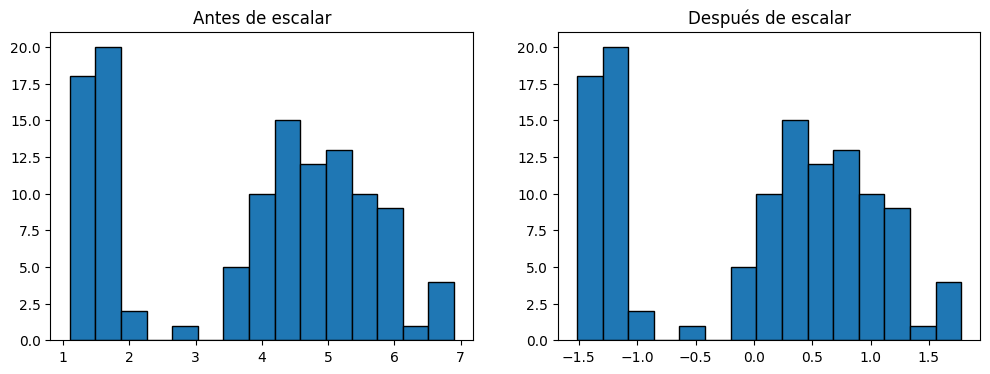

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(X_train["petal length (cm)"], bins=15, edgecolor="black")
axes[0].set_title("Antes de escalar")

axes[1].hist(X_train_scaled["petal length (cm)"], bins=15, edgecolor="black")
axes[1].set_title("Después de escalar")

plt.show()


# 7. Pipeline


## 7.1 Model Selection

### Razones formales para emplear una MLP en este escenario

Un MLP es apropiado aquí porque:

1. El problema es supervisado y multiclase.
2. Las relaciones entre sépalos y pétalos pueden no ser lineales.
3. Una MLP implementa composiciones de transformaciones:

$$
z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}, \qquad a^{(l)} = \phi(z^{(l)})
$$

lo cual permite construir fronteras de decisión complejas.

### Comparación conceptual con un modelo lineal
Un clasificador lineal impone una frontera del tipo:

$$
w^Tx + b = 0
$$

En cambio, un MLP puede aproximar funciones más expresivas por la composición de varias capas.


## 7.2 Model Training

In [ ]:

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10, 10),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


In [ ]:

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

predictions = mlp.predict(X_test_scaled)

print("Matriz de confusión:")
print(confusion_matrix(y_test, predictions))

print("\nReporte de clasificación:")
print(classification_report(y_test, predictions, target_names=iris.target_names))

print("Accuracy:", accuracy_score(y_test, predictions))


Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Accuracy: 0.9333333333333333


## 7.3 Prediction


Construimos una función que reciba un patrón de entrada y devuelva:

- clase predicha,
- nombre de la especie,
- probabilidades asociadas.


In [ ]:

def predict_flower(sample, model=mlp, scaler=scaler, feature_names=X.columns.tolist(), target_names=iris.target_names):
    sample_df = pd.DataFrame([sample])
    sample_df = sample_df[feature_names]
    sample_scaled = scaler.transform(sample_df)

    pred_class = int(model.predict(sample_scaled)[0])
    pred_name = target_names[pred_class]
    pred_probs = model.predict_proba(sample_scaled)[0]

    return pred_class, pred_name, pred_probs


In [ ]:

sample_flower = {
    "sepal length (cm)": 5.1,
    "sepal width (cm)": 3.5,
    "petal length (cm)": 1.4,
    "petal width (cm)": 0.2
}

pred_class, pred_name, pred_probs = predict_flower(sample_flower)

print("Clase predicha:", pred_class)
print("Especie predicha:", pred_name)
print("Probabilidades:", pred_probs)


Clase predicha: 0
Especie predicha: setosa
Probabilidades: [9.99558116e-01 4.35079079e-04 6.80538275e-06]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
